In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


pd.set_option("display.max_columns", None)

## task 1

In [2]:
df = pd.read_csv("hotel_bookings.csv")

print("Shape:", df.shape)
df.head()

Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
print("Dataset Info")
df.info()

print("\nData Types")
display(df.dtypes)

print("\nSummary Statistics")
display(df.describe(include="all"))

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             


Summary Statistics


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [4]:
# Target
y = df["is_canceled"]

# Features
X = df.drop(columns=["is_canceled"])

# Identify feature types
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Numerical features: 19
Categorical features: 12


,Class,Count,Percentage
0,0,75166,62.96
1,1,44224,37.04


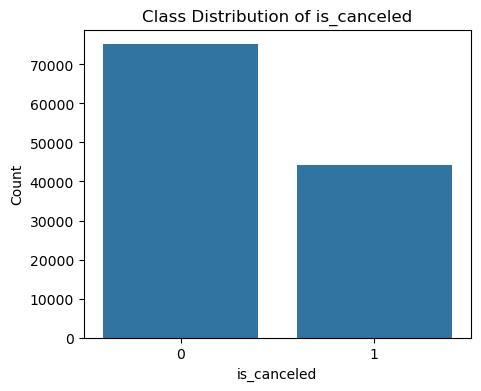

In [5]:
class_dist = y.value_counts().rename_axis("Class").reset_index(name="Count")
class_dist["Percentage"] = (class_dist["Count"] / len(y) * 100).round(2)

display(class_dist)

plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution of is_canceled")
plt.xlabel("is_canceled")
plt.ylabel("Count")
plt.show()

## task 2

In [6]:
missing_count = X.isnull().sum()
missing_percent = (missing_count / len(X) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Values": missing_count,
    "Percentage": missing_percent
}).sort_values("Percentage", ascending=False)

missing_df[missing_df["Missing Values"] > 0]

,Missing Values,Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


In [7]:
# Company has more than 90% missing values, so it is removed.
X = X.drop(columns=["company"])

print("Remaining shape:", X.shape)

Remaining shape: (119390, 30)


In [8]:
leakage_cols = ["reservation_status", "reservation_status_date"]

X = X.drop(columns=leakage_cols)

print("Leakage columns removed.")
X.head()

Leakage columns removed.


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,0,Transient,0.0,0,0
1,Resort Hotel,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,0,Transient,0.0,0,0
2,Resort Hotel,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,0,Transient,75.0,0,0
3,Resort Hotel,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0
4,Resort Hotel,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1


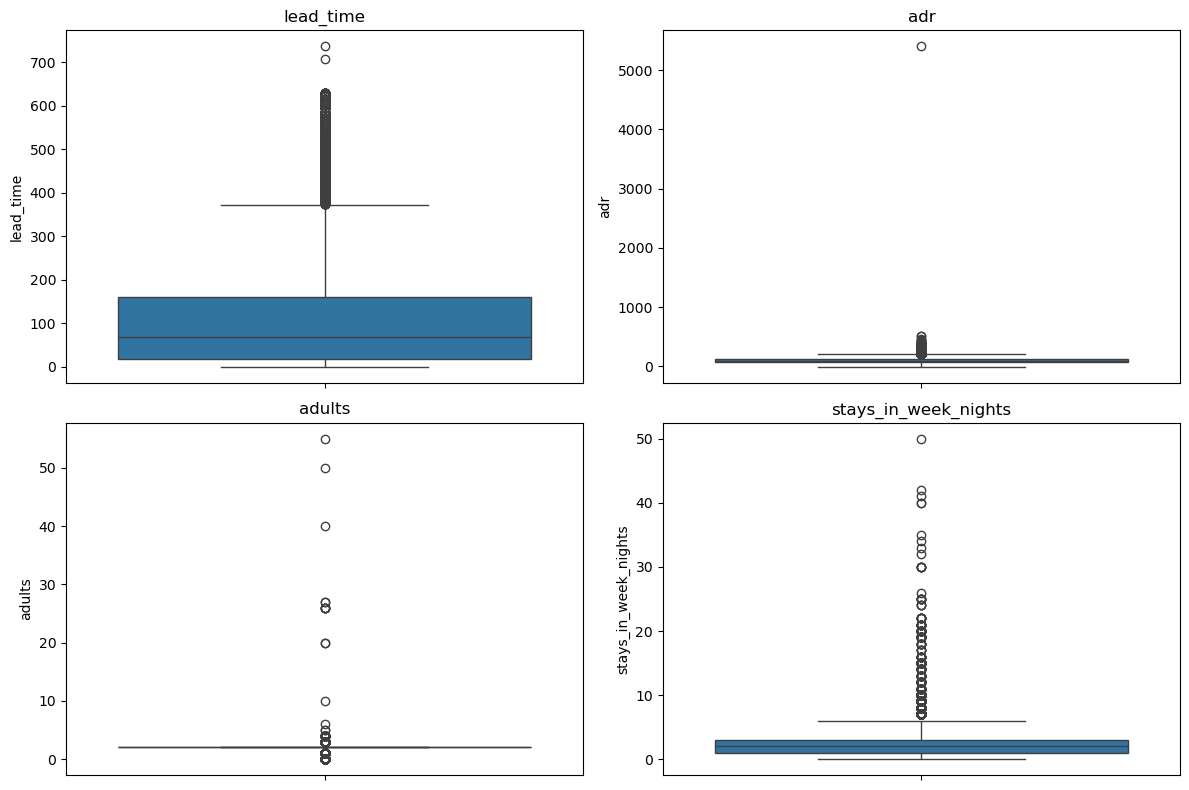

In [9]:
features = ["lead_time", "adr", "adults", "stays_in_week_nights"]

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [10]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

Q1 = X[numerical_cols].quantile(0.25)
Q3 = X[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~(
    ((X[numerical_cols] < (Q1 - 1.5 * IQR)) |
     (X[numerical_cols] > (Q3 + 1.5 * IQR)))
    .any(axis=1)
)

rows_before = len(X)

X = X[mask].reset_index(drop=True)
y = y[mask].reset_index(drop=True)

rows_after = len(X)

print("Rows removed:", rows_before - rows_after)
print("New dataset shape:", X.shape)

Rows removed: 64266
New dataset shape: (55124, 28)


## task 3

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (44099, 28)
Testing set : (11025, 28)


In [12]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:", len(numerical_cols))
print("Categorical columns:", len(categorical_cols))

Numerical columns: 18
Categorical columns: 10


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

In [14]:
numeric_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_A = ColumnTransformer([
    ("num", numeric_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

In [15]:
numeric_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

preprocessor_B = ColumnTransformer([
    ("num", numeric_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

print("Both preprocessing pipelines are ready.")

Both preprocessing pipelines are ready.


## task 4

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [17]:
lr_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

lr_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [18]:
lr_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

lr_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [19]:
dt_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

In [20]:
dt_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', DecisionTreeClassifier(random_state=42))])

## task 5

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [22]:
results = []

models = {
    "Logistic + StandardScaler": lr_A,
    "Logistic + MinMaxScaler": lr_B,
    "Decision Tree + StandardScaler": dt_A,
    "Decision Tree + MinMaxScaler": dt_B
}

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1-Score": f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results).round(4)
results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic + StandardScaler,0.7796,0.7838,0.7738,0.6416,0.7016
1,Logistic + MinMaxScaler,0.7796,0.7831,0.7729,0.6407,0.7006
2,Decision Tree + StandardScaler,0.9951,0.8300,0.7883,0.7804,0.7843
3,Decision Tree + MinMaxScaler,0.9951,0.8302,0.7887,0.7804,0.7845


In [23]:
results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Decision Tree + MinMaxScaler,0.9951,0.8302,0.7887,0.7804,0.7845
1,Decision Tree + StandardScaler,0.9951,0.8300,0.7883,0.7804,0.7843
2,Logistic + StandardScaler,0.7796,0.7838,0.7738,0.6416,0.7016
3,Logistic + MinMaxScaler,0.7796,0.7831,0.7729,0.6407,0.7006


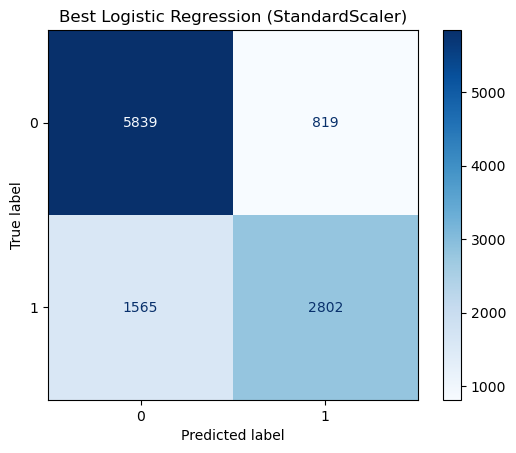

In [24]:
logistic_models = {
    "StandardScaler": lr_A,
    "MinMaxScaler": lr_B
}

best_lr_name = max(
    logistic_models,
    key=lambda k: f1_score(y_test, logistic_models[k].predict(X_test))
)

best_lr = logistic_models[best_lr_name]
lr_pred = best_lr.predict(X_test)

cm = confusion_matrix(y_test, lr_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title(f"Best Logistic Regression ({best_lr_name})")
plt.show()

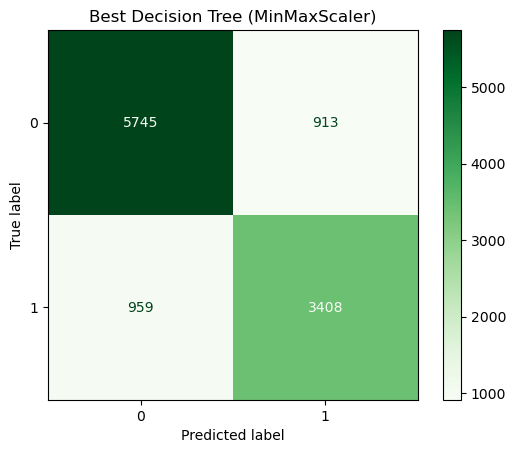

In [25]:
tree_models = {
    "StandardScaler": dt_A,
    "MinMaxScaler": dt_B
}

best_dt_name = max(
    tree_models,
    key=lambda k: f1_score(y_test, tree_models[k].predict(X_test))
)

best_dt = tree_models[best_dt_name]
dt_pred = best_dt.predict(X_test)

cm = confusion_matrix(y_test, dt_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Greens")
plt.title(f"Best Decision Tree ({best_dt_name})")
plt.show()

In [26]:
overfitting = results_df[["Model", "Train Accuracy", "Test Accuracy"]].copy()
overfitting["Difference"] = (
    overfitting["Train Accuracy"] - overfitting["Test Accuracy"]
).round(4)

overfitting

,Model,Train Accuracy,Test Accuracy,Difference
0,Logistic + StandardScaler,0.7796,0.7838,-0.0042
1,Logistic + MinMaxScaler,0.7796,0.7831,-0.0035
2,Decision Tree + StandardScaler,0.9951,0.8300,0.1651
3,Decision Tree + MinMaxScaler,0.9951,0.8302,0.1649


## task 6

In [27]:
best_model = results_df.loc[results_df["F1-Score"].idxmax()]

print("Best Overall Combination")
print("-" * 35)
print(f"Model      : {best_model['Model']}")
print(f"Test Acc.  : {best_model['Test Accuracy']:.4f}")
print(f"Precision  : {best_model['Precision']:.4f}")
print(f"Recall     : {best_model['Recall']:.4f}")
print(f"F1-Score   : {best_model['F1-Score']:.4f}")

Best Overall Combination
-----------------------------------
Model      : Decision Tree + MinMaxScaler
Test Acc.  : 0.8302
Precision  : 0.7887
Recall     : 0.7804
F1-Score   : 0.7845


In [28]:
logistic_results = results_df[results_df["Model"].str.contains("Logistic")].reset_index(drop=True)
logistic_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Logistic + StandardScaler,0.7796,0.7838,0.7738,0.6416,0.7016
1,Logistic + MinMaxScaler,0.7796,0.7831,0.7729,0.6407,0.7006


In [29]:
tree_results = results_df[results_df["Model"].str.contains("Decision Tree")].reset_index(drop=True)
tree_results

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1-Score
0,Decision Tree + StandardScaler,0.9951,0.8300,0.7883,0.7804,0.7843
1,Decision Tree + MinMaxScaler,0.9951,0.8302,0.7887,0.7804,0.7845


## Final Observations

1. **Best overall model:** Decision Tree with **MinMaxScaler** achieved the highest performance, with **83.02% testing accuracy** and an **F1-score of 0.7845**.

2. **Effect of scaling on Logistic Regression:** StandardScaler performed slightly better than MinMaxScaler, but the difference was very small, indicating that both scaling methods produced similar results.

3. **Effect of scaling on Decision Tree:** StandardScaler and MinMaxScaler resulted in nearly identical performance, showing that feature scaling has very little impact on Decision Tree models.

4. **Overfitting:** Logistic Regression showed good generalization because its training and testing accuracies were very close. Decision Tree showed signs of overfitting, with **99.51% training accuracy** compared to **83.02% testing accuracy**.

5. **Conclusion:** Decision Tree provided the best predictive performance, while Logistic Regression was the more stable model due to its smaller train–test accuracy gap.